In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date

# DORA & NIS2 Requirements Tracker
data = {
    'Requirement': [
        'ICT Risk Management Framework',
        'Incident Classification & Reporting',
        'Digital Operational Resilience Testing',
        'Third Party ICT Risk Management',
        'Information Sharing',
        'Network & Information Security Policy',
        'Incident Response Plan',
        'Business Continuity Management',
        'Supply Chain Security',
        'Vulnerability Disclosure Policy'
    ],
    'Framework': [
        'DORA', 'DORA', 'DORA', 'DORA', 'DORA',
        'NIS2', 'NIS2', 'NIS2', 'NIS2', 'NIS2'
    ],
    'Status': [
        'In Progress', 'Compliant', 'Not Started',
        'In Progress', 'Not Started',
        'Compliant', 'In Progress', 'Not Started',
        'In Progress', 'Not Started'
    ],
    'Priority': [
        'Critical', 'Critical', 'High',
        'Critical', 'Medium',
        'Critical', 'Critical', 'High',
        'High', 'Medium'
    ],
    'Deadline': [
        '2025-01-17', '2025-01-17', '2025-01-17',
        '2025-01-17', '2025-01-17',
        '2024-10-18', '2024-10-18', '2024-10-18',
        '2024-10-18', '2024-10-18'
    ],
    'Owner': [
        'Risk', 'Security', 'IT',
        'Risk', 'Security',
        'Security', 'Security', 'Risk',
        'Risk', 'IT'
    ],
    'Progress': [45, 100, 0, 60, 0, 100, 70, 10, 50, 0]
}

df = pd.DataFrame(data)
df['Deadline'] = pd.to_datetime(df['Deadline'])
print("DORA & NIS2 Tracker loaded!")
df

DORA & NIS2 Tracker loaded!


,Requirement,Framework,Status,Priority,Deadline,Owner,Progress
0,ICT Risk Management Framework,DORA,In Progress,Critical,2025-01-17,Risk,45
1,Incident Classification & Reporting,DORA,Compliant,Critical,2025-01-17,Security,100
2,Digital Operational Resilience Testing,DORA,Not Started,High,2025-01-17,IT,0
3,Third Party ICT Risk Management,DORA,In Progress,Critical,2025-01-17,Risk,60
4,Information Sharing,DORA,Not Started,Medium,2025-01-17,Security,0
5,Network & Information Security Policy,NIS2,Compliant,Critical,2024-10-18,Security,100
6,Incident Response Plan,NIS2,In Progress,Critical,2024-10-18,Security,70
7,Business Continuity Management,NIS2,Not Started,High,2024-10-18,Risk,10
8,Supply Chain Security,NIS2,In Progress,High,2024-10-18,Risk,50
9,Vulnerability Disclosure Policy,NIS2,Not Started,Medium,2024-10-18,IT,0


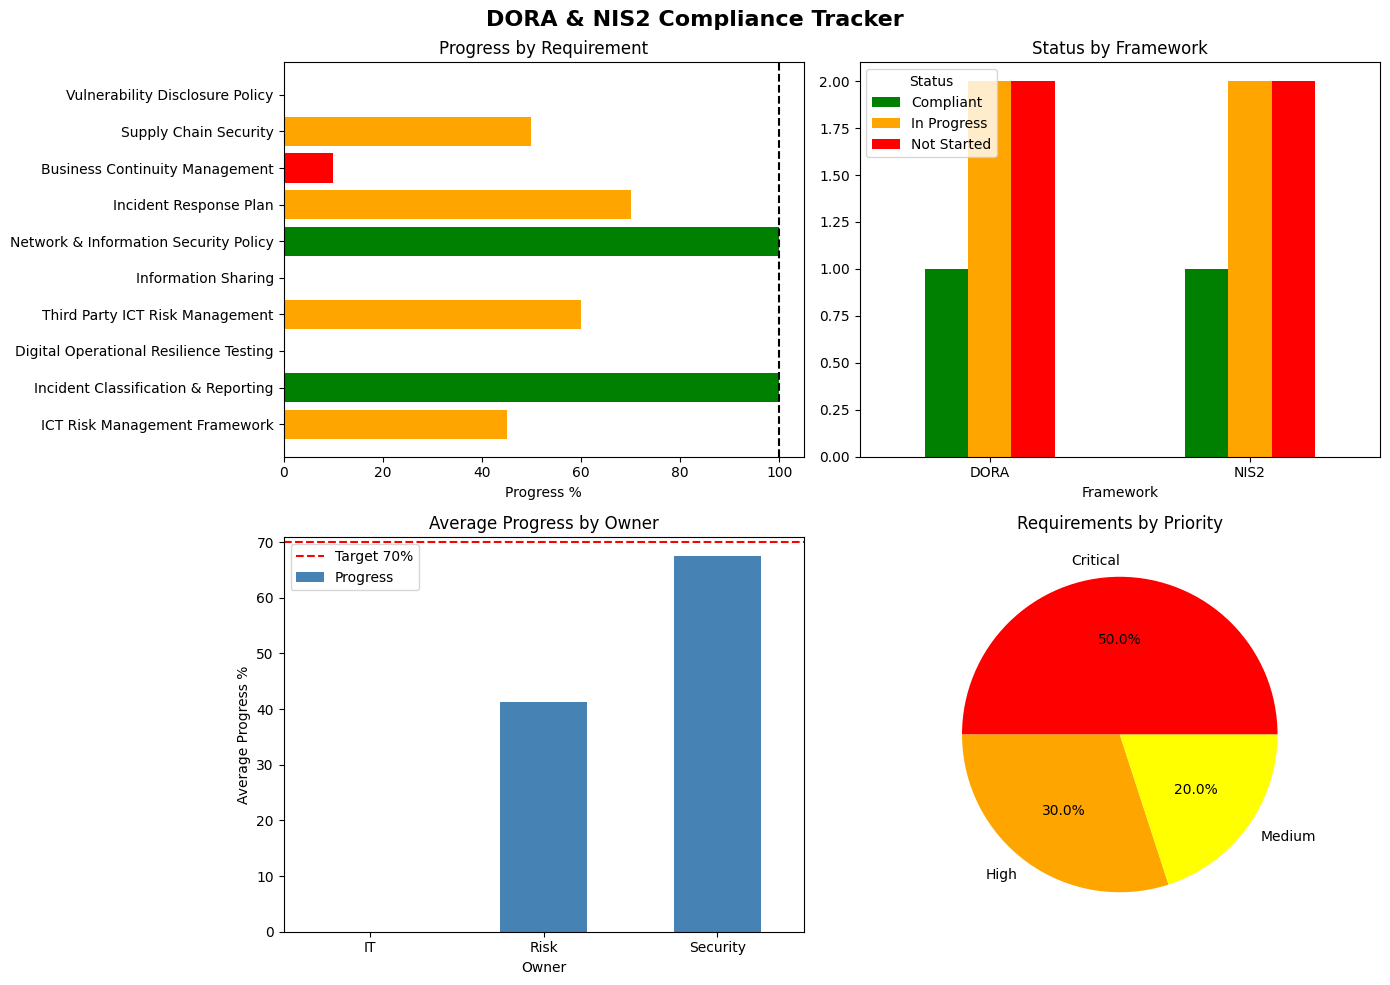

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DORA & NIS2 Compliance Tracker', fontsize=16, fontweight='bold')

# Chart 1 - Progress by Requirement
colors = df['Status'].map({
    'Compliant': 'green',
    'In Progress': 'orange',
    'Not Started': 'red'
})
axes[0,0].barh(df['Requirement'], df['Progress'], color=colors)
axes[0,0].axvline(x=100, color='black', linestyle='--')
axes[0,0].set_title('Progress by Requirement')
axes[0,0].set_xlabel('Progress %')

# Chart 2 - Status breakdown by Framework
status_framework = df.groupby(['Framework', 'Status']).size().unstack(fill_value=0)
status_framework.plot(kind='bar', ax=axes[0,1], color=['green', 'orange', 'red'])
axes[0,1].set_title('Status by Framework')
axes[0,1].set_xlabel('Framework')
axes[0,1].tick_params(axis='x', rotation=0)

# Chart 3 - Progress by Owner
df.groupby('Owner')['Progress'].mean().plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Average Progress by Owner')
axes[1,0].set_xlabel('Owner')
axes[1,0].set_ylabel('Average Progress %')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].axhline(y=70, color='red', linestyle='--', label='Target 70%')
axes[1,0].legend()

# Chart 4 - Priority breakdown
priority_counts = df['Priority'].value_counts()
colors_pie = ['red', 'orange', 'yellow']
axes[1,1].pie(priority_counts, labels=priority_counts.index, 
              autopct='%1.1f%%', colors=colors_pie)
axes[1,1].set_title('Requirements by Priority')

plt.tight_layout()
plt.show()

In [3]:
print("=== DORA & NIS2 ACTION PLAN ===\n")

# Critical items not started
critical = df[(df['Priority'] == 'Critical') & (df['Status'] == 'Not Started')]
inprogress = df[(df['Status'] == 'In Progress') & (df['Progress'] < 50)]

print("🔴 IMMEDIATE ACTION REQUIRED:")
for _, row in critical.iterrows():
    print(f"  • {row['Requirement']} [{row['Framework']}] — Owner: {row['Owner']}")

print("\n🟠 NEEDS ACCELERATION:")
for _, row in inprogress.iterrows():
    print(f"  • {row['Requirement']} [{row['Framework']}] — {row['Progress']}% complete — Owner: {row['Owner']}")

print("\n🟢 COMPLIANT:")
for _, row in df[df['Status'] == 'Compliant'].iterrows():
    print(f"  • {row['Requirement']} [{row['Framework']}]")

print(f"\nOverall DORA Progress: {df[df['Framework']=='DORA']['Progress'].mean():.1f}%")
print(f"Overall NIS2 Progress: {df[df['Framework']=='NIS2']['Progress'].mean():.1f}%")
print(f"Overall Compliance Progress: {df['Progress'].mean():.1f}%")

=== DORA & NIS2 ACTION PLAN ===

🔴 IMMEDIATE ACTION REQUIRED:

🟠 NEEDS ACCELERATION:
  • ICT Risk Management Framework [DORA] — 45% complete — Owner: Risk

🟢 COMPLIANT:
  • Incident Classification & Reporting [DORA]
  • Network & Information Security Policy [NIS2]

Overall DORA Progress: 41.0%
Overall NIS2 Progress: 46.0%
Overall Compliance Progress: 43.5%
